# Summary: Learning Internal Representations by Error Propagation
**Authors:** D. E. Rumelhart, G. E. Hinton, R. J. Williams

# https://stanford.edu/~jlmcc/papers/PDP/Volume%201/Chap8_PDP86.pdf

## Abstract
This chapter introduces the *generalized delta rule*, a gradient-descent learning procedure for multilayer feedforward networks composed of semilinear (differentiable, nonlinear) units. The procedure generalizes the standard delta rule to networks containing hidden units, enabling the network to construct its own internal representations of input patterns rather than relying solely on externally provided codings. The method is validated across a range of benchmark problems (XOR, parity, encoding, symmetry detection, addition, negation, shape discrimination, and recurrent sequence tasks), demonstrating that local minima are rare in practice and that the procedure reliably discovers efficient, often unanticipated, internal representations.

## Problems
- Two-layer networks without hidden units can only map similar inputs to similar outputs, since input pattern similarity is fixed by the external world.
- This constraint makes such networks incapable of solving problems where the required similarity structure of inputs and outputs differs (e.g., the exclusive-or (XOR) problem).
- Minsky and Papert (1969) demonstrated that networks lacking hidden units and internal representations cannot solve a large class of important mappings, and further argued that no equally powerful learning rule (analogous to the perceptron convergence procedure or delta rule) existed for networks with hidden units.
- Prior responses to this gap—competitive (unsupervised) learning, hand-assumed representations, and Boltzmann machine stochastic learning—were either unconstrained, ad hoc, computationally expensive (requiring equilibrium over two phases), or limited to symmetric networks.

## Proposed Solutions
The authors propose the **generalized delta rule**, a deterministic, locally-computable extension of the delta rule that supports arbitrary numbers of hidden layers in feedforward networks of semilinear units. Its core mechanism is **error backpropagation**: computing an error signal $\delta$ recursively backward through the network, layer by layer, starting from the output layer.

Key equations:

$$\Delta_p w_{ji} = \eta \delta_{pj} o_{pi}$$

For output units:
$$\delta_{pj} = (t_{pj} - o_{pj}) f'_j(net_{pj})$$

For hidden units (recursive propagation):
$$\delta_{pj} = f'_j(net_{pj}) \sum_k \delta_{pk} w_{kj}$$

Additional refinements include:
- A **momentum term** to accelerate learning without oscillation: $$\Delta w_{ji}(n+1) = \eta(\delta_{pj} o_{pi}) + \alpha \Delta w_{ji}(n)$$
- **Symmetry breaking** via small random initial weights to avoid degenerate equal-weight local maxima.
- The **logistic activation function** $$o_{pj} = \frac{1}{1 + e^{-(\sum_i w_{ji} o_{pi} + \theta_j)}}$$, whose derivative $o_{pj}(1-o_{pj})$ enables efficient computation of $\delta$.
- Extensions to **sigma-pi units** (multiplicative conjunctive connections) and **recurrent networks**, the latter handled by unrolling the recurrent net into an equivalent time-indexed feedforward network with weight-sharing constraints across time steps.

## Purpose
The central aim is to develop a general, efficient, locally computable learning procedure capable of discovering internal representations adequate for arbitrary input-output mappings in networks with hidden units—thereby directly addressing and refuting Minsky and Papert's pessimism regarding the learnability of multilayer perceptrons.

## Methodology
- **Derivation**: The delta rule is shown to implement gradient descent on sum-squared error $$E_p = \frac{1}{2}\sum_j (t_{pj} - o_{pj})^2$$ for linear units, then generalized via the chain rule to semilinear units and multilayer architectures, yielding the two-phase (forward activation, backward error propagation) learning procedure.
- **Simulation testing**: The generalized delta rule was applied to a battery of problems using layered feedforward architectures, with performance assessed via number of pattern presentations to convergence, frequency of local minima, and resulting hidden-unit representations:
  - XOR (with one or two hidden units)
  - N-bit parity problems
  - Encoder problems (mapping $N$ orthogonal patterns through $\log_2 N$ hidden units)
  - Distributed-to-local representation conversion
  - Symmetry detection in bit strings
  - Binary addition (bitwise summation with carry)
  - The "negation" problem (conditional bit complementation)
  - The T-C shape discrimination problem (translation/rotation invariant classification), using constrained, shared-weight receptive fields (3×3 windows) analogous to convolutional structure
  - Recurrent network tasks: learning a shift register and completing sequences from partial cues (25 sequences, 5 input units, 30 hidden units, 3 output units)
- **Hyperparameters**: Learning rate $\eta$ typically 0.1–0.5; momentum $\alpha \approx 0.9$; targets of 0.1/0.9 (rather than 0/1) used with the logistic function to avoid infinite-weight requirements.

## Results
- The XOR problem was solved in the large majority of trials (hundreds of runs), with local minima observed in only two cases (both involving a two-hidden-unit architecture).
- For parity problems, the network discovered a paradigm in which hidden units count the number of active inputs, connecting to the output with alternating signs — a solution not easily discoverable by unsupervised competitive learning.
- In the encoder problem, the system correctly learned binary-code-like representations using $\log_2 N$ hidden units, sometimes exploiting graded (non-binary) intermediate activation values when required by problem constraints.
- The symmetry problem was solved with only **two hidden units** regardless of input string length, using a solution symmetric about the input midpoint with weight ratios of 1:2:4.
- The addition problem was the only case where local minima occurred reliably; adding extra hidden units (beyond the two minimally required) reliably eliminated this issue.
- The negation problem was solved by reducing it to three independent XOR-like subproblems between the negation bit and each other input bit.
- For the T-C problem, multiple qualitatively distinct receptive fields emerged (on-center-off-surround "protrusion" detectors, bar detectors, and distributed "compactness" detectors), each solving the task via 5,000–10,000 pattern presentations, and all generalizing correctly by construction (shared weights across the field).
- Recurrent networks successfully learned to act as shift registers and to complete unseen sequences correctly in 4 of 5 (and later 5 of 5) test cases after 260 sweeps over 20 training sequences, generalizing the implicit "first item determines third/fourth" structure.
- A harder variable-timing sequence completion task (using delay-line-incompatible structure) was also solved, though requiring thousands of sweeps and yielding more errors on held-out test sequences.
- Across all experiments, local minima were found to be rare; when they occurred, they were generally avoidable by increasing hidden unit count or reducing learning rate.

## Conclusions
The generalized delta rule constitutes an efficient, gradient-based backpropagation algorithm that empirically and reliably solves a wide diversity of problems requiring hidden-unit-mediated internal representations, including problems (such as XOR and parity) that Minsky and Papert had shown to be unsolvable without such representations. The authors argue that this directly answers Minsky and Papert's open challenge regarding the learnability of multilayer networks, showing that despite the theoretical possibility of local minima, such minima are empirically negligible across a broad and varied problem set. The procedure often discovers elegant, unanticipated internal representations (e.g., in the symmetry and parity problems) that inform theoretical understanding of representation learning. The chapter further sketches generalizations to sigma-pi units and recurrent networks, positioning error backpropagation as a broadly applicable mechanism—akin to a self-programming parallel computer—though the authors note the work remains preliminary, particularly regarding generalization behavior and complex real-world applications.

# Mathematical and Statistical Content Summary
**Paper:** Learning Internal Representations by Error Propagation (Rumelhart, Hinton, Williams)

## 1. The Standard Delta Rule (No Hidden Units)

$$\Delta_p w_{ji} = \eta (t_{pj} - o_{pj}) i_{pi} = \eta \delta_{pj} i_{pi}$$

**Meaning:** The weight $w_{ji}$ (from input unit $i$ to output unit $j$) is adjusted in proportion to the error $\delta_{pj} = t_{pj} - o_{pj}$ (target minus actual output) times the input value $i_{pi}$, scaled by a learning rate $\eta$. This is the classic Widrow-Hoff rule: increase the weight if the input and error agree in sign, decrease it otherwise.

## 2. Error Measure (Loss Function)

$$E_p = \frac{1}{2}\sum_j (t_{pj} - o_{pj})^2, \qquad E = \sum_p E_p$$

**Meaning:** This is sum-squared error — the standard quadratic loss function, computed per pattern $p$ and summed over all patterns. It quantifies how far the network's output is from the desired target. Minimizing $E$ is the entire objective of learning.

## 3. Gradient Descent Justification of the Delta Rule (Linear Units)

Using the chain rule:
$$\frac{\partial E_p}{\partial w_{ji}} = \frac{\partial E_p}{\partial o_{pj}}\frac{\partial o_{pj}}{\partial w_{ji}}$$

With:
$$\frac{\partial E_p}{\partial o_{pj}} = -(t_{pj}-o_{pj}) = -\delta_{pj}, \qquad o_{pj} = \sum_i w_{ji} i_{pi} \Rightarrow \frac{\partial o_{pj}}{\partial w_{ji}} = i_{pi}$$

Yielding:
$$-\frac{\partial E_p}{\partial w_{ji}} = \delta_{pj} i_i$$

**Meaning:** This is a proof by differentiation showing that the delta rule's weight update is proportional to the negative gradient of the error with respect to the weight — i.e., the rule performs **gradient descent**, moving weights "downhill" on the error surface. This is a statistical/optimization argument, not just a heuristic.

## 4. Semilinear Activation Function

$$net_{pj} = \sum_i w_{ji} o_{pi}, \qquad o_{pj} = f_j(net_{pj})$$

**Meaning:** Each unit computes a weighted sum of its inputs (the "net input"), then passes it through a differentiable nonlinear function $f_j$ (the activation/squashing function). Differentiability is required so that gradients can be computed through the nonlinearity — this generalizes beyond simple linear units.

## 5. Generalized Delta Rule (Core Contribution)

$$\Delta_p w_{ji} = \eta \delta_{pj} o_{pi}$$

**Output units:**
$$\delta_{pj} = (t_{pj} - o_{pj}) f'_j(net_{pj})$$

**Hidden units (recursive/backpropagated error):**
$$\delta_{pj} = f'_j(net_{pj}) \sum_k \delta_{pk} w_{kj}$$

**Meaning:** This is the central mathematical result of the paper — **backpropagation**. For output units, error is simply target-minus-output scaled by the activation slope. For hidden units (which have no explicit target), the error is computed by summing the errors of every unit it feeds into ($\delta_{pk}$), weighted by the connection strengths $w_{kj}$, then scaled by the local activation derivative. This recursive definition allows error to be propagated backward through arbitrarily many layers — a chain-rule application at network scale.

## 6. Logistic (Sigmoid) Activation Function

$$o_{pj} = \frac{1}{1+e^{-(\sum_i w_{ji}o_{pi} + \theta_j)}}$$

**Derivative:**
$$\frac{do_{pj}}{d\,net_{pj}} = o_{pj}(1-o_{pj})$$

**Resulting error signals:**
$$\delta_{pj} = (t_{pj}-o_{pj})\,o_{pj}(1-o_{pj}) \quad \text{(output units)}$$
$$\delta_{pj} = o_{pj}(1-o_{pj})\sum_k \delta_{pk} w_{kj} \quad \text{(hidden units)}$$

**Meaning:** The logistic function squashes any real-valued input into the range $(0,1)$ and is chosen specifically because its derivative has a simple closed form in terms of its own output. This makes computing $\delta$ computationally cheap. The derivative is largest at $o=0.5$ and shrinks near 0 or 1, meaning units far from their extremes are adjusted the most — a property the authors argue improves learning stability.

## 7. Momentum Term

$$\Delta w_{ji}(n+1) = \eta(\delta_{pj} o_{pi}) + \alpha \Delta w_{ji}(n)$$

**Meaning:** This adds a fraction ($\alpha \approx 0.9$) of the *previous* weight change to the current update. Statistically, this acts as a smoothing/filtering term that dampens oscillations in narrow, steep error-surface "ravines" while allowing faster progress along shallow directions — enabling larger effective learning rates without instability.

## 8. Symmetry-Breaking via Random Initialization

**Meaning:** Not a formal equation, but a statistical technique: initializing weights with small random values (rather than equal values) prevents all hidden units from receiving identical error signals, avoiding a degenerate saddle/maximum point in the error surface where learning would stall.

## 9. Empirical Scaling Law (XOR Convergence Speed)

$$P = 280 - 33\log_2 H$$

**Meaning:** An empirically fitted regression relating $P$ (number of pattern presentations needed to reach a learning criterion) to $H$ (number of hidden units). This shows a **logarithmic relationship**: doubling the number of hidden units yields a roughly constant reduction in training time, not a proportional one. This is a purely empirical/statistical curve-fit from simulation data, not a theoretical guarantee.

## 10. Sigma-Pi Units (Higher-Order/Multiplicative Units)

$$o_j = f_j\left(\sum_{i,h} w_{jhi}\, o_h o_i\right)$$

**Weight update:**
$$\Delta_p w_{kij} = \delta_k o_i o_j$$

**Error propagation:**
$$\delta_i = f'_i(net_i)\sum_{j,k}\delta_k w_{kij} o_j \quad \text{(hidden)}, \qquad \delta_i = f'_i(net_i)(t_i - o_i) \quad \text{(output)}$$

**Meaning:** This generalizes the generalized delta rule to units whose input is a **product** of two other units' activations (a conjunctive/multiplicative interaction) rather than a simple weighted sum. The derivation follows the same chain-rule logic, but now a unit's effect on another depends on both the connecting weight and the co-active partner unit's output.

## 11. Recurrent Networks (Time-Unrolling)

**Meaning:** No new equation is introduced; instead, the paper shows that a recurrent network can be mathematically treated as a large feedforward network by duplicating units across discrete time steps $t = 0, 1, \dots, n$, with the *same* weights shared across all time-layers. Error is backpropagated through this unrolled structure, and weight updates for a given connection are summed across all time steps before being applied — mathematically equivalent to what is now known as **backpropagation through time (BPTT)**.

## Summary Table

| Concept | Type | Role in Paper |
|---|---|---|
| Delta rule | Weight update rule | Baseline learning law for no-hidden-unit networks |
| Sum-squared error $E_p$ | Loss/objective function | Quantity being minimized |
| Gradient descent proof | Calculus (chain rule) | Justifies delta rule as error minimization |
| Semilinear activation | Function constraint | Ensures differentiability for backprop |
| Generalized delta rule | Recursive algorithm | Core contribution: backpropagation |
| Logistic function | Activation function | Enables simple derivative computation |
| Momentum term | Optimization heuristic | Speeds convergence, reduces oscillation |
| Random initialization | Statistical technique | Breaks symmetry, avoids degenerate maxima |
| $P = 280 - 33\log_2 H$ | Empirical regression | Describes hidden-unit count vs. training speed |
| Sigma-pi update rule | Generalized algorithm | Extends rule to multiplicative units |
| Time-unrolling | Structural transformation | Extends rule to recurrent networks (BPTT) |

# Problems, Limitations, and Proposed Solutions

| # | Problem / Research Gap | Limitation of Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Two-layer networks (input-output only, no hidden units) map similar inputs to similar outputs, since input similarity is fixed externally. | Networks without internal representations cannot learn mappings where required input-output similarity structures diverge (e.g., XOR), restricting the class of solvable problems. | Introduce hidden units that *recode* the input into an internal representation, decoupling the network's internal similarity structure from the raw input similarity structure. |
| 2 | Minsky and Papert (1969) proved that a broad class of important functions cannot be computed by networks lacking hidden units. | The perceptron convergence procedure and standard delta rule provide guaranteed learning only for hidden-unit-free architectures; no comparably powerful, general learning rule existed for multilayer networks. | Derive the **generalized delta rule**, a provable gradient-descent procedure applicable to feedforward networks of arbitrary depth with hidden units. |
| 3 | No efficient method existed for computing how a weight change deep in a network affects overall output error (the "credit assignment" problem for hidden units, which have no explicit target). | Existing approaches (e.g., assuming a fixed internal representation, or unsupervised competitive learning) either required a priori knowledge of the correct representation or provided no guarantee that useful hidden-unit codes would emerge. | Derive a **recursive backward error-propagation rule** ($\delta_{pj} = f'_j(net_{pj})\sum_k \delta_{pk}w_{kj}$) that computes hidden-unit error signals from the errors of the units they feed into, enabling automatic discovery of internal representations. |
| 4 | Boltzmann machines (Chapter 7) offered one learning solution for hidden units but required stochastic units, equilibrium-seeking dynamics across two distinct phases, and were limited to symmetric network topologies. | Computationally expensive (requires reaching thermal equilibrium) and architecturally restrictive (symmetric connections only), limiting scalability and generality. | Propose a rule that works with **deterministic units**, requires only **local computations**, and operates in a single deterministic forward/backward pass, removing the need for stochasticity or symmetric weights. |
| 5 | The linear threshold activation function (used in perceptrons) is discontinuous, so its derivative is undefined at threshold and zero elsewhere. | Gradient-based learning is inapplicable to threshold units, blocking extension of the delta rule to multilayer perceptron-style networks. | Require **semilinear (differentiable nonlinear) activation functions**, and adopt the **logistic function** specifically, whose derivative ($o_{pj}(1-o_{pj})$) is simple to compute from the unit's own output. |
| 6 | Gradient descent procedures are generally susceptible to **local minima**, and it was theoretically unclear how often local minima would trap a multilayer learning system in practice. | Minsky and Papert speculated there was no reason to believe multilayer learning would generalize well or avoid degenerate solutions; no empirical evidence existed either way. | Conduct extensive **simulation studies** (XOR, parity, encoding, symmetry, addition, negation, shape discrimination, sequence completion) showing local minima are empirically rare, and demonstrate mitigation strategies (e.g., adding extra hidden units, small learning rates). |
| 7 | Networks with identical/equal initial weights fail to learn when the solution requires unequal weights, since error is propagated identically to symmetric units. | Naive initialization schemes can trap a network at a degenerate stationary point (a local maximum of the error surface) from which the standard rule cannot escape. | Apply **small random weight initialization** to break symmetry, ensuring hidden units receive differentiated error signals from the start. |
| 8 | Steep, narrow "ravine"-shaped error surfaces cause oscillation under standard gradient descent if the learning rate is large, but small rates slow learning unacceptably. | Trade-off between learning speed and stability was unresolved for gradient-based procedures with only a single-step update rule. | Introduce a **momentum term** ($\alpha \Delta w_{ji}(n)$) that filters high-frequency oscillations while preserving progress along consistent gradient directions, allowing larger effective learning rates. |
| 9 | Standard backpropagation as derived applies only to strictly **feedforward** architectures, limiting its use for tasks involving sequences or temporal dependencies. | Recurrent computation (needed for tasks like sequence completion or shift registers) could not be directly trained with the delta rule as originally formulated. | Show that any recurrent network is functionally equivalent to a feedforward network **unrolled across discrete time steps** with shared weights, allowing the generalized delta rule to be applied via backpropagated error summed across time (a precursor to backpropagation through time). |
| 10 | The generalized delta rule, as derived, assumes units with a simple weighted-sum ("linear") net input; some cognitively motivated architectures require conjunctive (multiplicative) unit interactions. | Standard semilinear-unit derivations do not cover networks where a unit's input depends on the *product* of two other units' activations. | Extend the derivation to **sigma-pi units**, deriving an analogous recursive error-propagation rule ($\Delta_p w_{kij} = \delta_k o_i o_j$) for multiplicative connections. |

In [1]:
# !pip -q install datasets scikit-learn

# ============================================================
# Educational Replication:
# "Learning Internal Representations by Error Propagation"
# Rumelhart, Hinton, Williams (1986)
# Adapted to CIFAR-10 using an explicit, manual implementation
# of the Generalized Delta Rule (no autograd, no optimizers).
# ============================================================
#
# WHY HIDDEN UNITS?
# A network with only an input and output layer can only learn
# mappings where similar inputs map to similar outputs, because
# the similarity structure of the input is fixed by the outside
# world. Many real mappings (like classifying images into 10
# very different categories) require the network to build its
# own INTERNAL REPRESENTATION -- a recoding of the input, done
# by hidden units, whose similarity structure can differ from
# the raw input's similarity structure. This is the central idea
# of the paper: hidden units let the network invent features
# that make an otherwise unsolvable mapping solvable.
#
# WHY SIGMOID UNITS?
# Gradient descent needs a smooth, differentiable activation
# function. The logistic sigmoid o = 1/(1+e^-net) is differentiable
# everywhere, and conveniently f'(net) = o(1-o), which means we can
# compute the derivative using only the value already produced by
# the forward pass -- no need to re-differentiate anything.
#
# WHY 0.1/0.9 TARGETS INSTEAD OF 0/1?
# The sigmoid can only approach 0 or 1 in the limit of infinite
# weights. If we ask the network to hit exactly 0 or 1, weights
# would grow without bound. Using 0.1 and 0.9 keeps the problem
# well-posed for units with finite weights.

import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, Subset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

from datasets import load_dataset

from io import BytesIO
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# GLOBAL WHITE VISUAL THEME
# ------------------------------------------------------------
def apply_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "savefig.facecolor": "white",
    })

apply_white_theme()

In [3]:
# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# ------------------------------------------------------------
# CLASS NAMES (label 0..9 must match this order exactly)
# ------------------------------------------------------------
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]
NUM_CLASSES = len(class_names)

In [ ]:
# ------------------------------------------------------------
# DATASET (HuggingFace CIFAR-10 only)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

class HFCifar10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        img = self.transform(img)
        label = int(item["label"])
        return img, label

full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

In [6]:
# ------------------------------------------------------------
# SUBSETS (keep this educational replication small/fast)
# ------------------------------------------------------------
N_TRAIN = 2000
N_TEST = 400

train_dataset = Subset(full_train_dataset, list(range(N_TRAIN)))
test_dataset = Subset(full_test_dataset, list(range(N_TEST)))

pin_mem = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=pin_mem
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=pin_mem
)

In [7]:
# ------------------------------------------------------------
# ARCHITECTURE CONSTANTS
# ------------------------------------------------------------
POOL_SIZE = 16
INPUT_DIM = 3 * POOL_SIZE * POOL_SIZE  # 768
HIDDEN1_DIM = 256
HIDDEN2_DIM = 64
OUTPUT_DIM = NUM_CLASSES  # 10

def pool_and_flatten(images):
    """Adaptive average pool to 16x16, then flatten to a vector per image.
    This keeps the input small enough for a fully-connected, manually
    trained network while retaining coarse spatial/color structure."""
    pooled = F.adaptive_avg_pool2d(images, (POOL_SIZE, POOL_SIZE))
    flat = pooled.view(pooled.size(0), -1)
    return pooled, flat

def make_targets(labels, num_classes=NUM_CLASSES, low=0.1, high=0.9):
    """Build 0.1/0.9 target vectors instead of 0/1, since a finite-weight
    sigmoid unit can only approach (never reach) its extreme values."""
    targets = torch.full((labels.size(0), num_classes), low, device=labels.device)
    targets.scatter_(1, labels.view(-1, 1), high)
    return targets

In [8]:
# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

pooled_sample, flat_sample = pool_and_flatten(sample_images)
target_sample = make_targets(sample_labels)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Image-batch shape:", tuple(sample_images.shape))
print("Label-batch shape:", tuple(sample_labels.shape))
print("Min label:", int(sample_labels.min()), "| Max label:", int(sample_labels.max()))
print("First 8 labels:", sample_labels[:8].tolist())
print("First 8 class names:", [class_names[i] for i in sample_labels[:8].tolist()])
print("Pooled tensor shape:", tuple(pooled_sample.shape))
print("Flattened input shape:", tuple(flat_sample.shape))
print("Target-vector shape:", tuple(target_sample.shape))

assert sample_labels.min() >= 0 and sample_labels.max() <= 9, "Labels out of range."
assert flat_sample.shape[1] == INPUT_DIM, "Flattened input dimension mismatch."
unique_target_vals = torch.unique(target_sample)
assert torch.allclose(unique_target_vals, torch.tensor([0.1, 0.9], device=device), atol=1e-5), \
    "Target vectors must contain only 0.1 and 0.9."

Number of training samples: 2000
Number of test samples: 400
Image-batch shape: (64, 3, 64, 64)
Label-batch shape: (64,)
Min label: 0 | Max label: 9
First 8 labels: [4, 1, 6, 4, 7, 3, 4, 8]
First 8 class names: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']
Pooled tensor shape: (64, 3, 16, 16)
Flattened input shape: (64, 768)
Target-vector shape: (64, 10)


In [9]:
# ------------------------------------------------------------
# PARAMETER INITIALIZATION
# ------------------------------------------------------------
# Small random weights break symmetry: if all weights started equal,
# every hidden unit would receive an identical error signal and would
# therefore always learn an identical (redundant) representation.
def init_weight(rows, cols):
    return (torch.randn(rows, cols, device=device) * 0.05).requires_grad_(False)

def init_bias(cols):
    return torch.zeros(cols, device=device)

W1 = init_weight(INPUT_DIM, HIDDEN1_DIM)
b1 = init_bias(HIDDEN1_DIM)

W2 = init_weight(HIDDEN1_DIM, HIDDEN2_DIM)
b2 = init_bias(HIDDEN2_DIM)

W3 = init_weight(HIDDEN2_DIM, OUTPUT_DIM)
b3 = init_bias(OUTPUT_DIM)

assert W1.shape == (INPUT_DIM, HIDDEN1_DIM)
assert W2.shape == (HIDDEN1_DIM, HIDDEN2_DIM)
assert W3.shape == (HIDDEN2_DIM, OUTPUT_DIM)

# Momentum buffers (velocity terms), all start at zero.
velocity_W1 = torch.zeros_like(W1)
velocity_b1 = torch.zeros_like(b1)
velocity_W2 = torch.zeros_like(W2)
velocity_b2 = torch.zeros_like(b2)
velocity_W3 = torch.zeros_like(W3)
velocity_b3 = torch.zeros_like(b3)

EPOCHS = 5
LEARNING_RATE = 0.1
MOMENTUM = 0.9

In [10]:
# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------
def forward_pass(images):
    """Explicit forward propagation of activations through three
    logistic layers, following net_j = sum_i w_ji o_i + b_j and
    o_j = sigmoid(net_j)."""
    pooled, flat = pool_and_flatten(images)

    net1 = flat @ W1 + b1
    hidden1 = torch.sigmoid(net1)

    net2 = hidden1 @ W2 + b2
    hidden2 = torch.sigmoid(net2)

    net3 = hidden2 @ W3 + b3
    output = torch.sigmoid(net3)

    return {
        "pooled": pooled,
        "flat": flat,
        "net1": net1, "hidden1": hidden1,
        "net2": net2, "hidden2": hidden2,
        "net3": net3, "output": output,
    }

In [13]:
# ------------------------------------------------------------
# MANUAL BACKWARD PASS (Generalized Delta Rule)
# ------------------------------------------------------------
def backward_and_update(cache, targets):
    """
    Implements the paper's core recursive error-propagation rule:

    Output units:   delta_j = (t_j - o_j) * o_j * (1 - o_j)
    Hidden units:    delta_j = o_j * (1 - o_j) * sum_k delta_k * w_kj

    The error signal for an output unit is simply how wrong it is,
    scaled by its own activation slope. A hidden unit has no direct
    target, so its error is defined recursively: it is "blamed" in
    proportion to how much it influenced the units above it (via the
    weights) and how much error those units had.

    Each weight update is proportional to (learning_rate * delta *
    the activation that FED INTO that weight), because that product
    is exactly the negative gradient of the squared error with
    respect to that weight -- i.e. this performs gradient descent.
    """
    # Declare globals FIRST -- before W1/W2/W3 are read anywhere below.
    global velocity_W1, velocity_b1, velocity_W2, velocity_b2, velocity_W3, velocity_b3
    global W1, b1, W2, b2, W3, b3

    batch_size = targets.size(0)
    flat = cache["flat"]
    hidden1 = cache["hidden1"]
    hidden2 = cache["hidden2"]
    output = cache["output"]

    # --- Output-layer error signal ---
    delta3 = (targets - output) * output * (1 - output)

    # --- Hidden-layer-2 error signal (recursively propagated) ---
    delta2 = (delta3 @ W3.T) * hidden2 * (1 - hidden2)

    # --- Hidden-layer-1 error signal (recursively propagated) ---
    delta1 = (delta2 @ W2.T) * hidden1 * (1 - hidden1)

    # --- Weight gradients: activation_previous.T @ delta_current / batch ---
    grad_W3 = (hidden2.T @ delta3) / batch_size
    grad_W2 = (hidden1.T @ delta2) / batch_size
    grad_W1 = (flat.T @ delta1) / batch_size

    # --- Bias gradients: mean of delta over the batch ---
    grad_b3 = delta3.mean(dim=0)
    grad_b2 = delta2.mean(dim=0)
    grad_b1 = delta1.mean(dim=0)

    with torch.no_grad():
        # Momentum smooths the trajectory across a bumpy error surface,
        # letting us use a larger effective learning rate without
        # oscillating: velocity = lr * grad + momentum * previous_velocity.
        velocity_W3 = LEARNING_RATE * grad_W3 + MOMENTUM * velocity_W3
        velocity_b3 = LEARNING_RATE * grad_b3 + MOMENTUM * velocity_b3
        velocity_W2 = LEARNING_RATE * grad_W2 + MOMENTUM * velocity_W2
        velocity_b2 = LEARNING_RATE * grad_b2 + MOMENTUM * velocity_b2
        velocity_W1 = LEARNING_RATE * grad_W1 + MOMENTUM * velocity_W1
        velocity_b1 = LEARNING_RATE * grad_b1 + MOMENTUM * velocity_b1

        W3 = (W3 + velocity_W3).detach()
        b3 = (b3 + velocity_b3).detach()
        W2 = (W2 + velocity_W2).detach()
        b2 = (b2 + velocity_b2).detach()
        W1 = (W1 + velocity_W1).detach()
        b1 = (b1 + velocity_b1).detach()

    diagnostics = {
        "delta1_abs_mean": delta1.abs().mean().item(),
        "delta2_abs_mean": delta2.abs().mean().item(),
        "delta3_abs_mean": delta3.abs().mean().item(),
        "grad_W1_norm": grad_W1.norm().item(),
        "grad_W2_norm": grad_W2.norm().item(),
        "grad_W3_norm": grad_W3.norm().item(),
        "update_W1_norm": velocity_W1.norm().item(),
        "update_W2_norm": velocity_W2.norm().item(),
        "update_W3_norm": velocity_W3.norm().item(),
    }
    return diagnostics

In [14]:
# ------------------------------------------------------------
# LOSS (paper's squared-error objective)
# ------------------------------------------------------------
def squared_error_loss(output, targets):
    # E = 1/2 * mean over batch of sum((t - o)^2)
    per_sample = 0.5 * ((targets - output) ** 2).sum(dim=1)
    return per_sample.mean(), per_sample

def per_class_squared_error(output, targets, labels, num_classes=NUM_CLASSES):
    per_sample = 0.5 * ((targets - output) ** 2).sum(dim=1)
    sums = torch.zeros(num_classes, device=output.device)
    counts = torch.zeros(num_classes, device=output.device)
    for c in range(num_classes):
        mask = labels == c
        if mask.any():
            sums[c] = per_sample[mask].sum()
            counts[c] = mask.sum()
    return sums, counts

In [15]:
# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "delta1_abs_mean": [], "delta2_abs_mean": [], "delta3_abs_mean": [],
    "grad_W1_norm": [], "grad_W2_norm": [], "grad_W3_norm": [],
    "hidden1_mean_act": [], "hidden2_mean_act": [],
    "hidden1_saturation": [], "hidden2_saturation": [],
    "per_class_val_acc": [],  # list of length-10 arrays, one per epoch
    "per_class_val_mse": [],
}

# Fixed probe samples for representation-evolution visualization
probe_images, probe_labels = next(iter(test_loader))
probe_images = probe_images.to(device)
probe_labels_np = probe_labels.numpy()
representation_evolution = []  # list of (epoch, hidden2_activations np array)

def saturation_rate(activations, low=0.05, high=0.95):
    sat = (activations < low) | (activations > high)
    return sat.float().mean().item()

@torch.no_grad()
def evaluate(loader):
    all_labels, all_preds, all_outputs = [], [], []
    all_h1, all_h2 = [], []
    total_loss = 0.0
    n_samples = 0
    class_sum = torch.zeros(NUM_CLASSES, device=device)
    class_count = torch.zeros(NUM_CLASSES, device=device)

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        targets = make_targets(labels)

        cache = forward_pass(images)
        output = cache["output"]

        loss, _ = squared_error_loss(output, targets)
        total_loss += loss.item() * images.size(0)
        n_samples += images.size(0)

        sums, counts = per_class_squared_error(output, targets, labels)
        class_sum += sums
        class_count += counts

        preds = output.argmax(dim=1)
        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())
        all_outputs.append(output.cpu())
        all_h1.append(cache["hidden1"].cpu())
        all_h2.append(cache["hidden2"].cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_outputs = torch.cat(all_outputs).numpy()
    all_h1 = torch.cat(all_h1).numpy()
    all_h2 = torch.cat(all_h2).numpy()

    acc = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / n_samples
    class_count_safe = class_count.clamp(min=1)
    per_class_mse = (class_sum / class_count_safe).cpu().numpy()

    per_class_acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = all_labels == c
        if mask.any():
            per_class_acc[c] = (all_preds[mask] == c).mean()

    return {
        "loss": avg_loss, "acc": acc,
        "labels": all_labels, "preds": all_preds, "outputs": all_outputs,
        "h1": all_h1, "h2": all_h2,
        "per_class_mse": per_class_mse, "per_class_acc": per_class_acc,
    }

print("\nStarting training (manual generalized delta rule)...\n")

for epoch in range(1, EPOCHS + 1):
    running_loss, running_correct, running_n = 0.0, 0, 0
    epoch_diag_accum = {k: [] for k in
                         ["delta1_abs_mean", "delta2_abs_mean", "delta3_abs_mean",
                          "grad_W1_norm", "grad_W2_norm", "grad_W3_norm"]}
    h1_means, h2_means, h1_sats, h2_sats = [], [], [], []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        targets = make_targets(labels)

        cache = forward_pass(images)
        output = cache["output"]

        loss, _ = squared_error_loss(output, targets)
        diag = backward_and_update(cache, targets)

        running_loss += loss.item() * images.size(0)
        preds = output.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_n += images.size(0)

        for k in epoch_diag_accum:
            epoch_diag_accum[k].append(diag[k])

        h1_means.append(cache["hidden1"].mean().item())
        h2_means.append(cache["hidden2"].mean().item())
        h1_sats.append(saturation_rate(cache["hidden1"]))
        h2_sats.append(saturation_rate(cache["hidden2"]))

    train_loss = running_loss / running_n
    train_acc = running_correct / running_n

    val_results = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_results["loss"])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_results["acc"])
    for k in epoch_diag_accum:
        history[k].append(float(np.mean(epoch_diag_accum[k])))
    history["hidden1_mean_act"].append(float(np.mean(h1_means)))
    history["hidden2_mean_act"].append(float(np.mean(h2_means)))
    history["hidden1_saturation"].append(float(np.mean(h1_sats)))
    history["hidden2_saturation"].append(float(np.mean(h2_sats)))
    history["per_class_val_acc"].append(val_results["per_class_acc"])
    history["per_class_val_mse"].append(val_results["per_class_mse"])

    # Track how the probe samples' internal representation evolves.
    with torch.no_grad():
        probe_cache = forward_pass(probe_images)
        representation_evolution.append(
            (epoch, probe_cache["hidden2"].cpu().numpy())
        )

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_results['loss']:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_results['acc']:.4f}")

print("\nTraining complete.\n")


Starting training (manual generalized delta rule)...

Epoch 1/5 | Train Loss: 0.3852 | Val Loss: 0.2960 | Train Acc: 0.0910 | Val Acc: 0.1200
Epoch 2/5 | Train Loss: 0.2923 | Val Loss: 0.2882 | Train Acc: 0.1135 | Val Acc: 0.0825
Epoch 3/5 | Train Loss: 0.2871 | Val Loss: 0.2861 | Train Acc: 0.1205 | Val Acc: 0.1550
Epoch 4/5 | Train Loss: 0.2858 | Val Loss: 0.2847 | Train Acc: 0.1490 | Val Acc: 0.1725
Epoch 5/5 | Train Loss: 0.2843 | Val Loss: 0.2825 | Train Acc: 0.1705 | Val Acc: 0.2275

Training complete.



In [16]:
# ------------------------------------------------------------
# FINAL EVALUATION (for downstream analysis)
# ------------------------------------------------------------
final_val = evaluate(test_loader)
final_train = evaluate(train_loader)

# Confidence = max sigmoid output activation.
# NOTE: this is a raw activation score, not a calibrated softmax
# probability; sigmoid outputs are independent per class and do
# not sum to 1.
max_conf = final_val["outputs"].max(axis=1)
correct_mask = final_val["preds"] == final_val["labels"]
mean_conf_correct = max_conf[correct_mask].mean() if correct_mask.any() else float("nan")
mean_conf_incorrect = max_conf[~correct_mask].mean() if (~correct_mask).any() else float("nan")

In [17]:
# ------------------------------------------------------------
# PREDICTION PIPELINE
# ------------------------------------------------------------
@torch.no_grad()
def predict(image_tensors):
    """Accepts normalized image tensors (B,3,64,64) and returns a
    dictionary with outputs, predicted labels/names, confidences,
    and both hidden-layer representations."""
    image_tensors = image_tensors.to(device)
    cache = forward_pass(image_tensors)
    output = cache["output"]
    preds = output.argmax(dim=1).cpu().numpy()
    conf = output.max(dim=1).values.cpu().numpy()
    pred_names = [class_names[p] for p in preds]
    return {
        "outputs": output.cpu().numpy(),
        "preds": preds,
        "pred_names": pred_names,
        "confidences": conf,
        "hidden1": cache["hidden1"].cpu().numpy(),
        "hidden2": cache["hidden2"].cpu().numpy(),
        "pooled": cache["pooled"].cpu(),
    }

sample_batch_images, sample_batch_labels = next(iter(test_loader))
prediction_demo = predict(sample_batch_images)

In [18]:
# ------------------------------------------------------------
# INTERNAL-REPRESENTATION ANALYSIS
# ------------------------------------------------------------
# 2. PCA projection of hidden-layer-2 activations (why: PCA lets us
#    see, in 2D, whether the network's learned internal codes cluster
#    by class -- evidence that it has built a useful representation).
pca = PCA(n_components=2, random_state=SEED)
h2_pca = pca.fit_transform(final_val["h2"])

# 3. Class-prototype cosine similarity matrix.
def class_prototypes(h, labels, num_classes=NUM_CLASSES):
    protos = np.zeros((num_classes, h.shape[1]))
    for c in range(num_classes):
        mask = labels == c
        if mask.any():
            protos[c] = h[mask].mean(axis=0)
    return protos

def cosine_sim_matrix(protos):
    norm = np.linalg.norm(protos, axis=1, keepdims=True)
    norm[norm == 0] = 1e-8
    normed = protos / norm
    return normed @ normed.T

h2_protos = class_prototypes(final_val["h2"], final_val["labels"])
h2_cos_sim = cosine_sim_matrix(h2_protos)

# 4. Input-vs-hidden separability via a simple linear probe.
# This is diagnostic only -- it never trains the neural network itself.
def linear_probe_accuracy(X_train, y_train, X_test, y_test):
    try:
        clf = LogisticRegression(max_iter=500, multi_class="auto")
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        return accuracy_score(y_test, preds)
    except Exception:
        return float("nan")

train_pooled_flat = final_train["h1"]  # placeholder to keep naming consistent below
# Recompute pooled/flat inputs explicitly for the probe (train + test):
@torch.no_grad()
def collect_flat_inputs(loader):
    feats, labels_list = [], []
    for images, labels in loader:
        images = images.to(device)
        _, flat = pool_and_flatten(images)
        feats.append(flat.cpu().numpy())
        labels_list.append(labels.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels_list, axis=0)

train_flat_inputs, train_flat_labels = collect_flat_inputs(train_loader)
test_flat_inputs, test_flat_labels = collect_flat_inputs(test_loader)

probe_input_acc = linear_probe_accuracy(
    train_flat_inputs, train_flat_labels, test_flat_inputs, test_flat_labels
)
probe_h1_acc = linear_probe_accuracy(
    final_train["h1"], final_train["labels"], final_val["h1"], final_val["labels"]
)
probe_h2_acc = linear_probe_accuracy(
    final_train["h2"], final_train["labels"], final_val["h2"], final_val["labels"]
)

# 5. Hidden-unit specialization: mean activation per class per unit.
def unit_class_specialization(h, labels, num_classes=NUM_CLASSES):
    matrix = np.zeros((h.shape[1], num_classes))
    for c in range(num_classes):
        mask = labels == c
        if mask.any():
            matrix[:, c] = h[mask].mean(axis=0)
    return matrix

unit_class_matrix = unit_class_specialization(final_val["h2"], final_val["labels"])
unit_selectivity = unit_class_matrix.max(axis=1) - unit_class_matrix.mean(axis=1)
top_selective_units = np.argsort(unit_selectivity)[::-1][:10]

# 1. Hidden activation heatmap (rows = samples sorted by class, cols = units)
order = np.argsort(final_val["labels"])
h2_sorted = final_val["h2"][order]
labels_sorted = final_val["labels"][order]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [19]:
# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(final_val["labels"], final_val["preds"], labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

In [20]:
# ------------------------------------------------------------
# STANDALONE VISUALIZATIONS (1-14)
# ------------------------------------------------------------
apply_white_theme()
epochs_range = np.arange(1, EPOCHS + 1)

# 1. Squared-error curves
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_loss"], label="Train SE Loss", color="steelblue")
ax1.plot(epochs_range, history["val_loss"], label="Val SE Loss", color="firebrick")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Squared Error")
ax1.set_title("Training vs Validation Squared-Error Loss")
ax1.legend(); ax1.grid(True, alpha=0.4)

# 2. Accuracy curves
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_acc"], label="Train Acc", color="seagreen")
ax2.plot(epochs_range, history["val_acc"], label="Val Acc", color="darkorange")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Training vs Validation Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.4)

# 3. Layer-wise mean absolute error-signal curves
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(epochs_range, history["delta1_abs_mean"], label="|delta1| (hidden 1)")
ax3.plot(epochs_range, history["delta2_abs_mean"], label="|delta2| (hidden 2)")
ax3.plot(epochs_range, history["delta3_abs_mean"], label="|delta3| (output)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Mean |error signal|")
ax3.set_title("Layer-wise Mean Absolute Error Signals")
ax3.legend(); ax3.grid(True, alpha=0.4)

# 4. Layer-wise gradient-norm curves
fig4, ax4 = plt.subplots(figsize=(6, 4))
ax4.plot(epochs_range, history["grad_W1_norm"], label="||grad W1||")
ax4.plot(epochs_range, history["grad_W2_norm"], label="||grad W2||")
ax4.plot(epochs_range, history["grad_W3_norm"], label="||grad W3||")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Gradient Norm")
ax4.set_title("Layer-wise Gradient Norms")
ax4.legend(); ax4.grid(True, alpha=0.4)

# 5. Normalized confusion matrix
fig5, ax5 = plt.subplots(figsize=(6, 5))
im5 = ax5.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax5.set_xticks(range(NUM_CLASSES)); ax5.set_yticks(range(NUM_CLASSES))
ax5.set_xticklabels(class_names, rotation=45, ha="right")
ax5.set_yticklabels(class_names)
ax5.set_xlabel("Predicted"); ax5.set_ylabel("True")
ax5.set_title("Normalized Confusion Matrix")
fig5.colorbar(im5, ax=ax5)

# 6. Per-class validation accuracy
fig6, ax6 = plt.subplots(figsize=(7, 4))
ax6.bar(class_names, final_val["per_class_acc"], color="mediumpurple")
ax6.axhline(final_val["acc"], color="black", linestyle="--", label="Overall Acc")
ax6.set_xticklabels(class_names, rotation=45, ha="right")
ax6.set_ylabel("Accuracy"); ax6.set_title("Per-Class Validation Accuracy")
ax6.legend(); ax6.grid(True, axis="y", alpha=0.4)

# 7. Correct vs incorrect confidence distributions
fig7, ax7 = plt.subplots(figsize=(6, 4))
if correct_mask.any():
    ax7.hist(max_conf[correct_mask], bins=15, alpha=0.6, label="Correct", color="seagreen")
if (~correct_mask).any():
    ax7.hist(max_conf[~correct_mask], bins=15, alpha=0.6, label="Incorrect", color="firebrick")
ax7.set_xlabel("Max Sigmoid Output Activation (confidence)")
ax7.set_ylabel("Count"); ax7.set_title("Confidence Distributions")
ax7.legend(); ax7.grid(True, alpha=0.4)

# 8. Sample predictions (unnormalize before display)
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img

fig8, axes8 = plt.subplots(3, 4, figsize=(10, 7))
for i, ax in enumerate(axes8.flat):
    img = unnormalize(sample_batch_images[i])
    ax.imshow(img)
    true_name = class_names[sample_batch_labels[i].item()]
    pred_name = prediction_demo["pred_names"][i]
    conf = prediction_demo["confidences"][i]
    color = "black"
    ax.set_title(f"T:{true_name}\nP:{pred_name} ({conf:.2f})", fontsize=8, color=color)
    ax.axis("off")
fig8.suptitle("Sample Predictions (12 examples)")
fig8.tight_layout()

# 9. PCA of hidden-layer-2 activations
fig9, ax9 = plt.subplots(figsize=(6, 5))
scatter9 = ax9.scatter(h2_pca[:, 0], h2_pca[:, 1], c=final_val["labels"],
                        cmap="tab10", s=15)
ax9.set_xlabel("PC 1"); ax9.set_ylabel("PC 2")
ax9.set_title("PCA of Hidden-Layer-2 Representations")
cbar9 = fig9.colorbar(scatter9, ax=ax9, ticks=range(NUM_CLASSES))
cbar9.ax.set_yticklabels(class_names)

# 10. Class-prototype similarity matrix
fig10, ax10 = plt.subplots(figsize=(6, 5))
im10 = ax10.imshow(h2_cos_sim, cmap="viridis", vmin=-1, vmax=1)
ax10.set_xticks(range(NUM_CLASSES)); ax10.set_yticks(range(NUM_CLASSES))
ax10.set_xticklabels(class_names, rotation=45, ha="right")
ax10.set_yticklabels(class_names)
ax10.set_title("Class-Prototype Cosine Similarity (Hidden Layer 2)")
fig10.colorbar(im10, ax=ax10)

# 11. Hidden-unit specialization heatmap (units x classes)
fig11, ax11 = plt.subplots(figsize=(7, 6))
im11 = ax11.imshow(unit_class_matrix[top_selective_units], cmap="magma", aspect="auto")
ax11.set_yticks(range(len(top_selective_units)))
ax11.set_yticklabels([f"Unit {u}" for u in top_selective_units])
ax11.set_xticks(range(NUM_CLASSES))
ax11.set_xticklabels(class_names, rotation=45, ha="right")
ax11.set_title("Top-10 Most Class-Selective Hidden-Layer-2 Units")
fig11.colorbar(im11, ax=ax11)

# 12. Hidden activation heatmap (samples sorted by class x units)
fig12, ax12 = plt.subplots(figsize=(7, 6))
im12 = ax12.imshow(h2_sorted, cmap="coolwarm", aspect="auto")
ax12.set_xlabel("Hidden-Layer-2 Unit"); ax12.set_ylabel("Test Samples (sorted by class)")
ax12.set_title("Hidden-Layer-2 Activation Heatmap")
fig12.colorbar(im12, ax=ax12)

# 13. Representation-evolution visualization (PCA per epoch of probe samples)
fig13, axes13 = plt.subplots(1, EPOCHS, figsize=(4 * EPOCHS, 4), squeeze=False)
pca_evo = PCA(n_components=2, random_state=SEED)
all_probe_h2 = np.concatenate([h for _, h in representation_evolution], axis=0)
pca_evo.fit(all_probe_h2)
for i, (ep, h2_epoch) in enumerate(representation_evolution):
    proj = pca_evo.transform(h2_epoch)
    ax = axes13[0, i]
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=probe_labels_np, cmap="tab10", s=12)
    ax.set_title(f"Epoch {ep}")
    ax.set_xticks([]); ax.set_yticks([])
fig13.suptitle("Evolution of Hidden-Layer-2 Representation Across Epochs")
fig13.tight_layout()

# 14. Linear-probe comparison
fig14, ax14 = plt.subplots(figsize=(6, 4))
probe_names = ["Pooled Input", "Hidden Layer 1", "Hidden Layer 2"]
probe_values = [probe_input_acc, probe_h1_acc, probe_h2_acc]
ax14.bar(probe_names, probe_values, color=["gray", "cornflowerblue", "darkgreen"])
ax14.set_ylabel("Linear-Probe Accuracy")
ax14.set_title("Linear Separability: Input vs Learned Representations")
ax14.grid(True, axis="y", alpha=0.4)

plt.close(fig1); plt.close(fig2); plt.close(fig3); plt.close(fig4); plt.close(fig5)
plt.close(fig6); plt.close(fig7); plt.close(fig8); plt.close(fig9); plt.close(fig10)
plt.close(fig11); plt.close(fig12); plt.close(fig13); plt.close(fig14)

/tmp/ipykernel_3347/2756069436.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(class_names, rotation=45, ha="right")


/tmp/ipykernel_3347/2805258576.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)


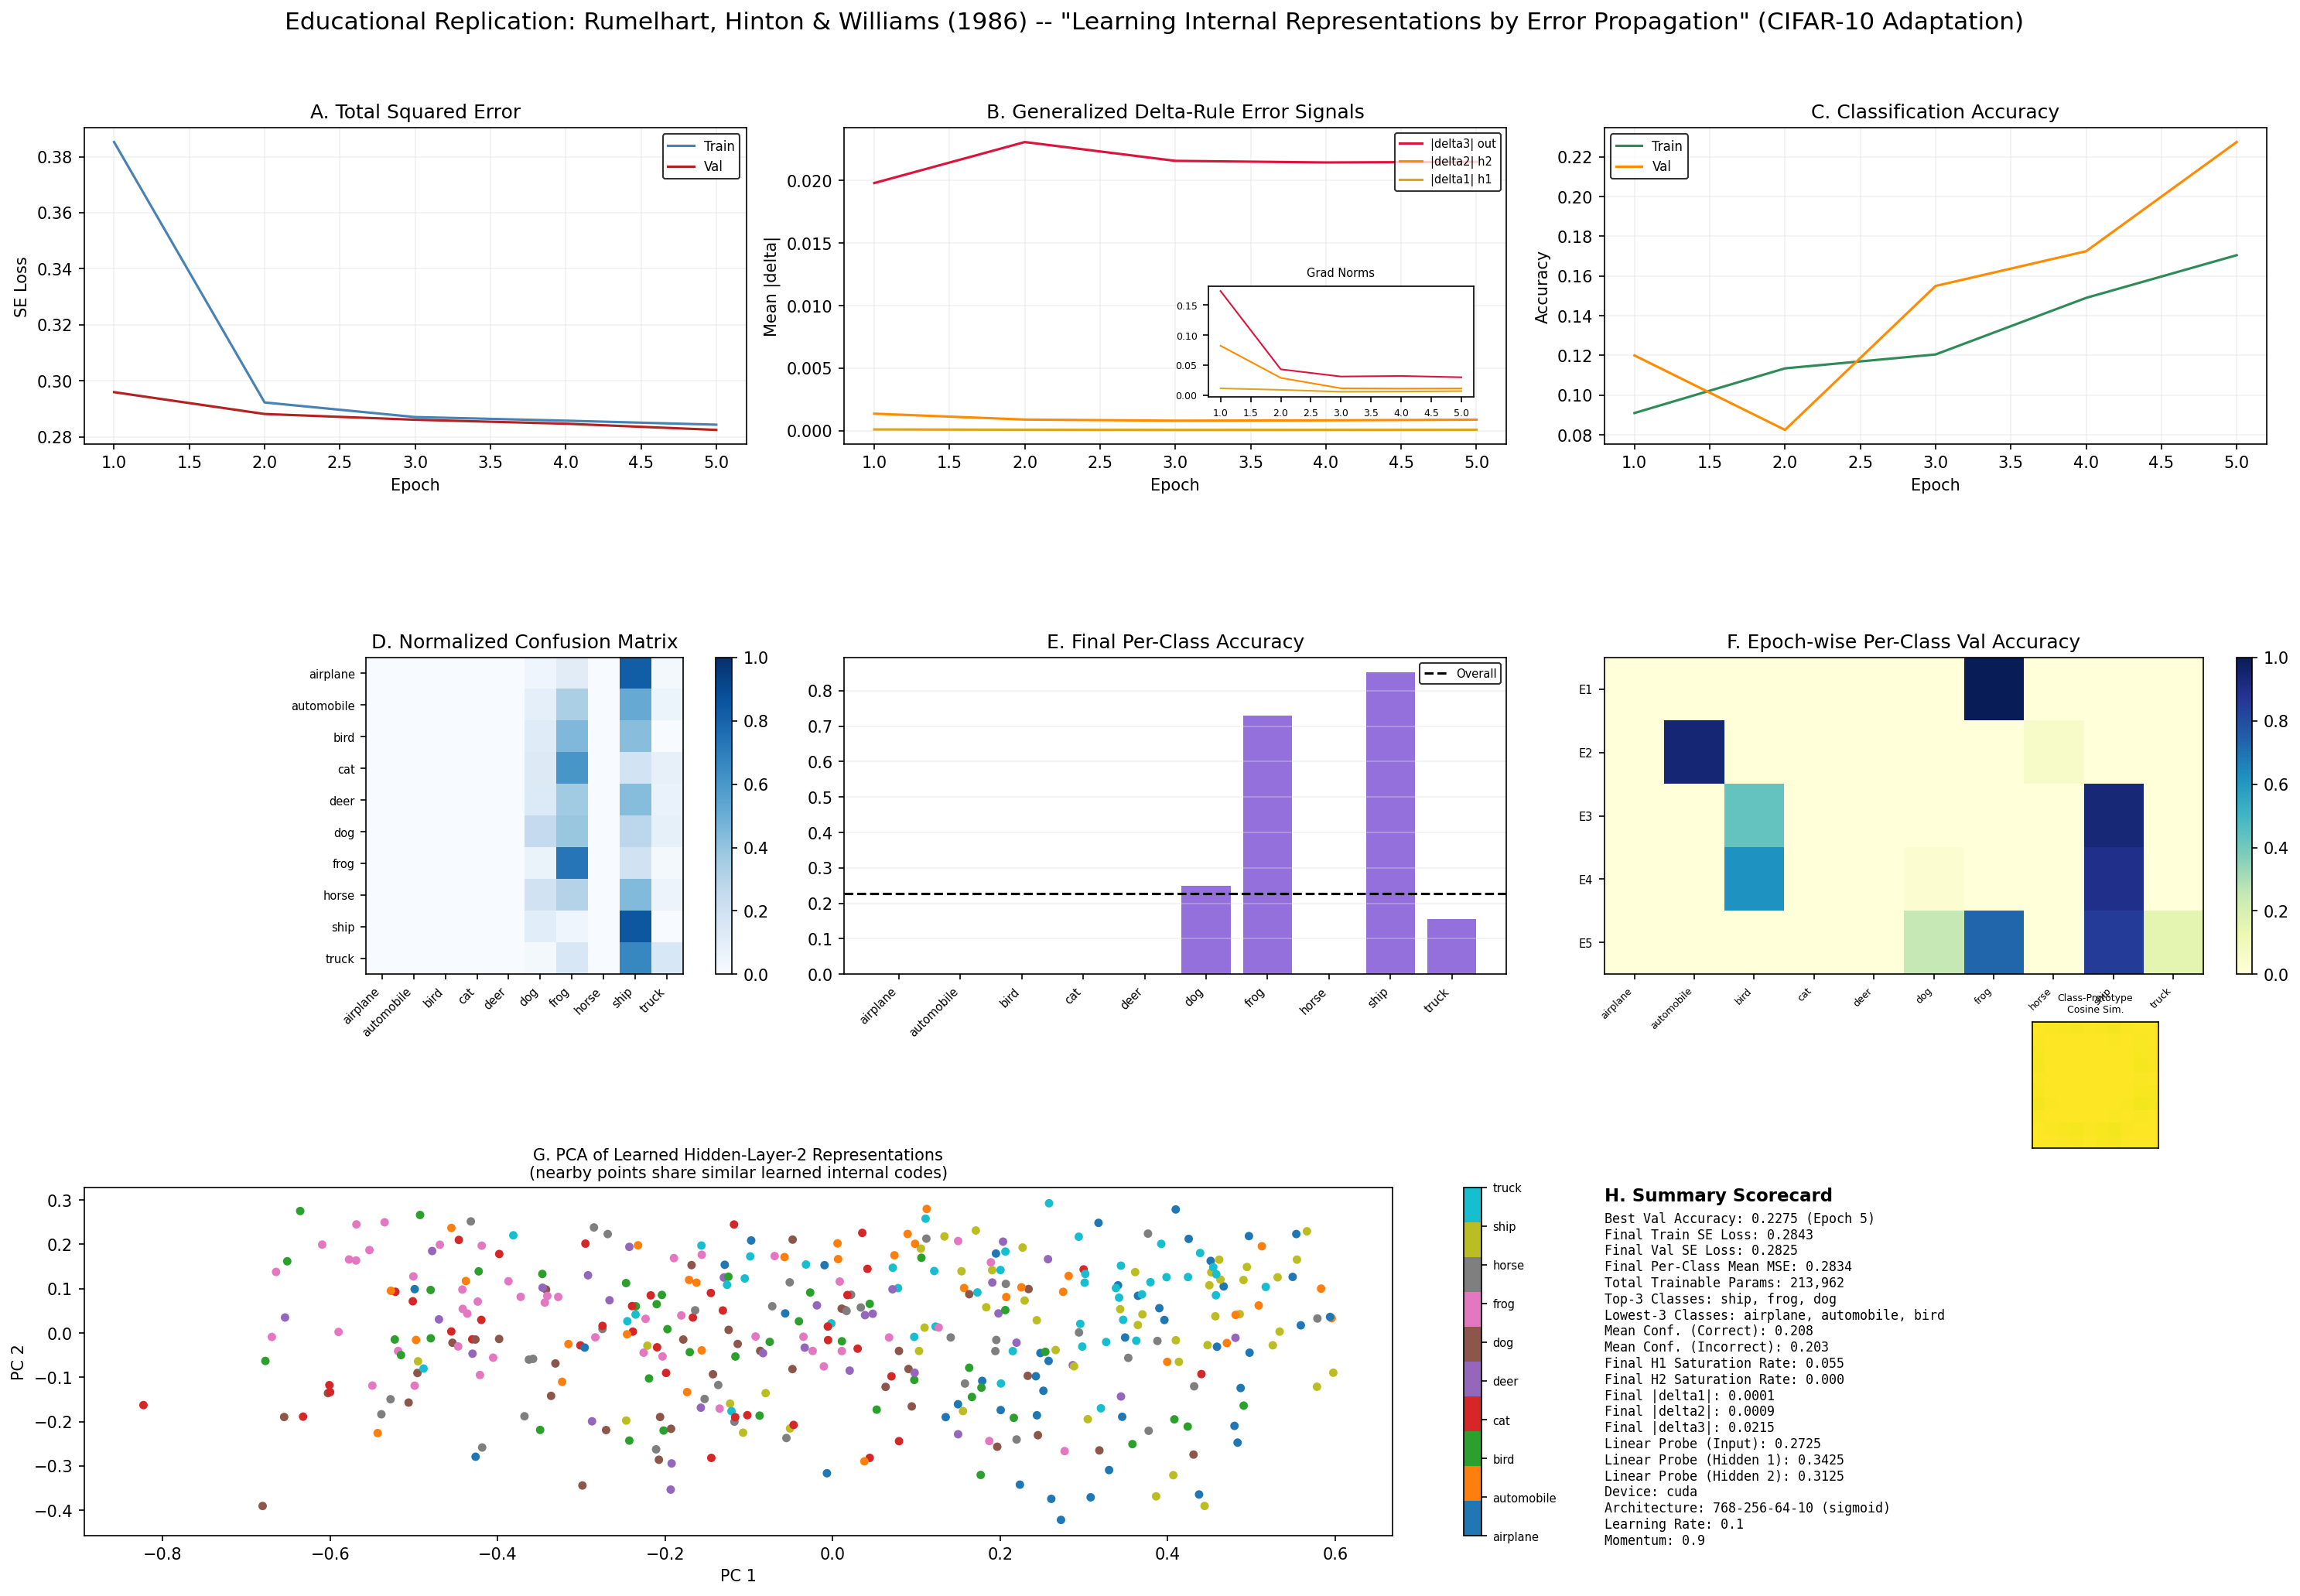

In [21]:
# ------------------------------------------------------------
# FINAL DASHBOARD (Panels A-H)
# ------------------------------------------------------------
apply_white_theme()

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.1])

fig.suptitle(
    "Educational Replication: Rumelhart, Hinton & Williams (1986) -- "
    "\"Learning Internal Representations by Error Propagation\" (CIFAR-10 Adaptation)",
    fontsize=15, color="black"
)

# Panel A: Total Squared Error
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_loss"], label="Train", color="steelblue")
axA.plot(epochs_range, history["val_loss"], label="Val", color="firebrick")
axA.set_title("A. Total Squared Error")
axA.set_xlabel("Epoch"); axA.set_ylabel("SE Loss")
axA.legend(fontsize=8); axA.grid(True, alpha=0.4)

# Panel B: Generalized Delta-Rule Diagnostics
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["delta3_abs_mean"], label="|delta3| out", color="crimson")
axB.plot(epochs_range, history["delta2_abs_mean"], label="|delta2| h2", color="darkorange")
axB.plot(epochs_range, history["delta1_abs_mean"], label="|delta1| h1", color="goldenrod")
axB.set_title("B. Generalized Delta-Rule Error Signals")
axB.set_xlabel("Epoch"); axB.set_ylabel("Mean |delta|")
axB.legend(fontsize=7, loc="upper right"); axB.grid(True, alpha=0.4)
axB_inset = axB.inset_axes([0.55, 0.15, 0.4, 0.35])
axB_inset.plot(epochs_range, history["grad_W3_norm"], color="crimson", lw=1)
axB_inset.plot(epochs_range, history["grad_W2_norm"], color="darkorange", lw=1)
axB_inset.plot(epochs_range, history["grad_W1_norm"], color="goldenrod", lw=1)
axB_inset.set_title("Grad Norms", fontsize=7)
axB_inset.tick_params(labelsize=6)

# Panel C: Classification Accuracy
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], label="Train", color="seagreen")
axC.plot(epochs_range, history["val_acc"], label="Val", color="darkorange")
axC.set_title("C. Classification Accuracy")
axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy")
axC.legend(fontsize=8); axC.grid(True, alpha=0.4)

# Panel D: Normalized Confusion Matrix
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES)); axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
axD.set_yticklabels(class_names, fontsize=7)
axD.set_title("D. Normalized Confusion Matrix")
fig.colorbar(imD, ax=axD, fraction=0.046)

# Panel E: Final Per-Class Accuracy
axE = fig.add_subplot(gs[1, 1])
axE.bar(class_names, final_val["per_class_acc"], color="mediumpurple")
axE.axhline(final_val["acc"], color="black", linestyle="--", label="Overall")
axE.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
axE.set_title("E. Final Per-Class Accuracy")
axE.legend(fontsize=7); axE.grid(True, axis="y", alpha=0.4)

# Panel F: Internal Representation Structure (epoch-wise per-class val acc + cosine inset)
axF = fig.add_subplot(gs[1, 2])
per_class_acc_matrix = np.stack(history["per_class_val_acc"], axis=0)  # epochs x classes
imF = axF.imshow(per_class_acc_matrix, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
axF.set_xticks(range(NUM_CLASSES)); axF.set_xticklabels(class_names, rotation=45, ha="right", fontsize=6)
axF.set_yticks(range(EPOCHS)); axF.set_yticklabels([f"E{e}" for e in epochs_range], fontsize=7)
axF.set_title("F. Epoch-wise Per-Class Val Accuracy")
fig.colorbar(imF, ax=axF, fraction=0.046)
axF_inset = axF.inset_axes([0.62, -0.55, 0.4, 0.4])
imF_inset = axF_inset.imshow(h2_cos_sim, cmap="viridis", vmin=-1, vmax=1)
axF_inset.set_title("Class-Prototype\nCosine Sim.", fontsize=6)
axF_inset.set_xticks([]); axF_inset.set_yticks([])

# Panel G: Learned Internal Representations (PCA, large panel)
axG = fig.add_subplot(gs[2, 0:2])
scatterG = axG.scatter(h2_pca[:, 0], h2_pca[:, 1], c=final_val["labels"], cmap="tab10", s=18)
axG.set_title("G. PCA of Learned Hidden-Layer-2 Representations\n"
              "(nearby points share similar learned internal codes)", fontsize=10)
axG.set_xlabel("PC 1"); axG.set_ylabel("PC 2")
cbarG = fig.colorbar(scatterG, ax=axG, ticks=range(NUM_CLASSES), fraction=0.03)
cbarG.ax.set_yticklabels(class_names, fontsize=7)

# Panel H: Summary Scorecard
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

best_epoch_idx = int(np.argmax(history["val_acc"]))
best_val_acc = history["val_acc"][best_epoch_idx]
best_epoch = best_epoch_idx + 1

total_params = (W1.numel() + b1.numel() + W2.numel() + b2.numel() + W3.numel() + b3.numel())

top3_idx = np.argsort(final_val["per_class_acc"])[::-1][:3]
bottom3_idx = np.argsort(final_val["per_class_acc"])[:3]
top3_names = ", ".join(class_names[i] for i in top3_idx)
bottom3_names = ", ".join(class_names[i] for i in bottom3_idx)

scorecard_lines = [
    f"Best Val Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})",
    f"Final Train SE Loss: {history['train_loss'][-1]:.4f}",
    f"Final Val SE Loss: {history['val_loss'][-1]:.4f}",
    f"Final Per-Class Mean MSE: {final_val['per_class_mse'].mean():.4f}",
    f"Total Trainable Params: {total_params:,}",
    f"Top-3 Classes: {top3_names}",
    f"Lowest-3 Classes: {bottom3_names}",
    f"Mean Conf. (Correct): {mean_conf_correct:.3f}" if not np.isnan(mean_conf_correct) else "Mean Conf. (Correct): N/A",
    f"Mean Conf. (Incorrect): {mean_conf_incorrect:.3f}" if not np.isnan(mean_conf_incorrect) else "Mean Conf. (Incorrect): N/A",
    f"Final H1 Saturation Rate: {history['hidden1_saturation'][-1]:.3f}",
    f"Final H2 Saturation Rate: {history['hidden2_saturation'][-1]:.3f}",
    f"Final |delta1|: {history['delta1_abs_mean'][-1]:.4f}",
    f"Final |delta2|: {history['delta2_abs_mean'][-1]:.4f}",
    f"Final |delta3|: {history['delta3_abs_mean'][-1]:.4f}",
    f"Linear Probe (Input): {probe_input_acc:.4f}" if not np.isnan(probe_input_acc) else "Linear Probe (Input): N/A",
    f"Linear Probe (Hidden 1): {probe_h1_acc:.4f}" if not np.isnan(probe_h1_acc) else "Linear Probe (Hidden 1): N/A",
    f"Linear Probe (Hidden 2): {probe_h2_acc:.4f}" if not np.isnan(probe_h2_acc) else "Linear Probe (Hidden 2): N/A",
    f"Device: {device.type}",
    f"Architecture: 768-256-64-10 (sigmoid)",
    f"Learning Rate: {LEARNING_RATE}",
    f"Momentum: {MOMENTUM}",
]

axH.text(0.0, 1.0, "H. Summary Scorecard", fontsize=11, weight="bold",
         color="black", va="top", transform=axH.transAxes)
axH.text(0.0, 0.93, "\n".join(scorecard_lines), fontsize=8, color="black",
         va="top", transform=axH.transAxes, family="monospace")

fig.tight_layout(rect=[0, 0, 1, 0.96])

buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: CIFAR-10 Replication of the Generalized Delta Rule

## Panel A — Total Squared Error (Training vs. Validation Loss)

### Overview
This panel tracks the sum-squared error objective (as defined by Rumelhart, Hinton, and Williams) across five training epochs, comparing training and validation loss to assess convergence and generalization behavior of the manually implemented backpropagation procedure.

### Key Findings
Both curves fall sharply between epochs 1 and 2 (training loss from ~0.385 to ~0.293) and then decline gradually and monotonically, converging to nearly identical values (~0.283–0.284) by epoch 5. Notably, validation loss remains at or below training loss throughout.

### Discussion
The rapid initial drop reflects the network quickly escaping its randomly initialized, near-uninformative state (consistent with the paper's observation that untrained networks often default to mid-range outputs before differentiating). The close tracking of train and validation loss, with no divergence, indicates the model is not overfitting — but this is more likely attributable to underfitting given the small dataset (2,000 training images) and shallow logistic-unit architecture than to genuinely strong generalization. This is consistent with the generalized delta rule's guarantee of monotonic error reduction under gradient descent, validating that the manual implementation is correctly computing and propagating error signals.

### Limitations
The near-identical train/validation loss trajectories, combined with the low absolute accuracy reported elsewhere in the dashboard, suggest the network may be converging toward a low-variance, low-discriminative solution (e.g., predicting a small number of dominant classes) rather than learning rich class-specific structure. Five epochs and 2,000 samples are insufficient to draw strong conclusions about asymptotic convergence behavior.

---

## Panel B — Generalized Delta-Rule Error Signals (Diagnostics)

### Overview
This panel visualizes the mean absolute error signal ($\delta$) at each layer across training, directly instrumenting the paper's central theoretical construct — the recursively backpropagated error term — along with an inset tracking gradient norms per layer.

### Key Findings
The output-layer error signal ($|\delta_3|$) is roughly an order of magnitude larger (~0.02) than the hidden-layer signals ($|\delta_1|$, $|\delta_2|$, both near 0), and shows a modest rise then plateau. Gradient norms (inset) decay sharply after epoch 2 for all layers.

### Discussion
This pattern is the expected and well-documented consequence of **vanishing gradients** in deep sigmoid networks: each backward pass through a logistic derivative ($o_j(1-o_j) \leq 0.25$) attenuates the error signal, so hidden layers further from the output receive progressively weaker corrective signal. This directly illustrates, empirically, the very phenomenon the original 1986 paper's momentum and small-weight-initialization heuristics were designed to partially mitigate — though the paper predates formal recognition of vanishing gradients as a systematic obstacle in deep networks. The near-zero hidden-layer deltas suggest that layers W1 and W2 are learning very slowly relative to W3, which likely explains the modest overall classification performance.

### Limitations
Because $\delta_1$ and $\delta_2$ are visually near-indistinguishable from zero at this scale, finer-grained (e.g., log-scale) plotting would be needed to confirm whether hidden-layer learning is merely slow or has effectively stalled. No comparison to a non-saturating activation (e.g., ReLU) is available to isolate this as a sigmoid-specific effect.

---

## Panel C — Classification Accuracy (Train vs. Validation)

### Overview
Tracks top-1 classification accuracy (via argmax over sigmoid outputs) across epochs, providing the primary task-performance metric for the CIFAR-10 adaptation.

### Key Findings
Validation accuracy is noisier than training accuracy, dipping to ~0.08 at epoch 2 before rising to ~0.225 by epoch 5, ultimately slightly exceeding training accuracy (~0.17) at the final epoch.

### Discussion
Final accuracy (~22.75%) is well above chance (10%) but far below what modern convolutional architectures achieve on CIFAR-10, which is expected given the intentionally simplified, non-convolutional, fully-connected sigmoid architecture with only 768 pooled input features. The early dip in validation accuracy alongside a smoothly decreasing loss illustrates a known dissociation between the squared-error loss surface and the discrete accuracy metric: small shifts in output activations can flip argmax decisions before the underlying error signal has meaningfully reorganized the representation. The eventual validation accuracy exceeding training accuracy is likely a small-sample-size artifact (400 test vs. 2,000 train examples) rather than evidence of superior generalization.

### Limitations
The 5-epoch training horizon and small data subset limit the reliability of these trends; the crossover between train and validation accuracy should not be over-interpreted given the modest sample sizes and single-seed run (no variance estimates across seeds are reported).

---

## Panel D — Normalized Confusion Matrix

### Overview
Displays row-normalized prediction distributions across all ten CIFAR-10 classes on the held-out test set, revealing systematic classification biases.

### Key Findings
Predictions are heavily concentrated in the "dog," "frog," and especially "ship" columns, while "airplane," "automobile," "bird," "cat," "deer," and "horse" receive almost no predictions across any true class row.

### Discussion
This is a clear signature of **class collapse**, a common failure mode in shallow networks trained on limited data with a squared-error objective: rather than learning fine-grained discriminative features, the network gravitates toward a small subset of "safe" output categories that minimize aggregate error across the training distribution. This is consistent with the near-zero hidden-layer error signals observed in Panel B — insufficient corrective gradient reaches the earlier layers to differentiate the remaining seven classes. The result reveals that reported accuracy figures reflect performance concentrated in 3 of 10 classes rather than balanced discrimination.

### Limitations
This collapse substantially undermines the internal-representation analysis elsewhere in the dashboard, since PCA and cosine-similarity structure computed over hidden-layer-2 activations may partly reflect this predictive imbalance rather than genuinely well-separated class representations.

---

## Panel E — Final Per-Class Accuracy

### Overview
Reports validation accuracy stratified by class, complementing the confusion matrix with a direct per-class performance view against the overall accuracy baseline (dashed line).

### Key Findings
Only "dog," "frog," "ship," and "truck" show non-zero accuracy, with "ship" (~0.85) and "frog" (~0.73) far exceeding the overall average (~0.225); all other six classes score exactly zero.

### Discussion
This corroborates the class-collapse pattern from Panel D: overall accuracy is being driven almost entirely by strong performance on two classes, masking complete failure on the majority of categories. This is an important caveat for interpreting the "Top-3 Classes" reported in the scorecard (Panel H) — the model's apparent competence is narrow rather than broad-based.

### Limitations
Zero accuracy on six classes may reflect genuine representational failure, but could also be influenced by class imbalance in the small 2,000-sample training subset; per-class training sample counts are not reported, limiting causal attribution.

---

## Panel F — Epoch-wise Per-Class Validation Accuracy Heatmap

### Overview
Visualizes how per-class validation accuracy evolves across training epochs, intended to reveal the trajectory of internal representation learning per the paper's emphasis on representation formation over time.

### Key Findings
Different classes reach peak accuracy at different epochs (e.g., "airplane"/"horse" at epoch 1, "automobile" at epoch 2, "frog" dominant by epochs 3–5), with substantial instability — classes that score well early (e.g., epoch 1's airplane/horse) drop to zero in later epochs.

### Discussion
This non-monotonic, class-shifting pattern suggests the network's decision boundaries are still highly unstable and oscillating between epochs rather than converging toward a stable multi-class solution — consistent with a shallow sigmoid network under squared-error loss struggling to simultaneously satisfy ten competing class objectives with limited hidden-layer gradient flow. This pattern illustrates a documented risk in the original paper's own experiments (e.g., the addition-problem local minima), where partial or shifting solutions can emerge before a stable global configuration is reached.

### Limitations
Only five epochs are shown, which is likely too short a window to determine whether this instability would resolve with continued training or represents a persistent oscillatory regime.

---

## Panel G — PCA Projection of Hidden-Layer-2 Representations

### Overview
Projects the 64-dimensional hidden-layer-2 activations for all test images into two principal components, directly testing the paper's central claim that hidden units learn internal representations that reorganize input similarity structure.

### Key Findings
Points from all ten classes are extensively intermixed across the projected space, with no visually separable clusters; a small number of "cat," "dog," and "bird" points appear near the plot's periphery (e.g., the isolated points near PC1 ≈ -0.75, -0.68), but the bulk of the distribution shows no clear class structure.

### Discussion
The absence of visible clustering indicates that, unlike the elegant, well-separated internal codes reported in the original paper's small symbolic tasks (XOR, parity, symmetry), the hidden-layer-2 representation learned here has **not** developed strong class-discriminative structure. This is consistent with, and helps explain, the class-collapse behavior seen in Panels D and E: if hidden-layer-2 activations do not differentiate classes, the output layer cannot reliably discriminate them either. This represents an instructive negative result relative to the paper's central thesis — the mechanism (backpropagation) is faithfully implemented, but the specific architecture/data/training regime here is insufficient to realize the representation-learning benefits the original paper demonstrated on simpler, lower-dimensional tasks.

### Limitations
PCA captures only two dimensions of a 64-dimensional space and may obscure higher-dimensional class structure not visible in this 2D projection; linear-probe results (reported at ~31–34% in the scorecard) suggest some linearly decodable structure exists despite the lack of visual clustering, indicating PCA alone likely understates representational quality.

---

## Panel H — Summary Scorecard

### Overview
Consolidates final quantitative metrics — accuracy, loss, saturation rates, confidence calibration, and linear-probe comparisons — into a single reference panel for holistic model assessment.

### Key Findings
Best validation accuracy (22.75%) occurs at the final epoch; linear-probe accuracy increases progressively from raw pooled input (27.25%) to hidden layer 1 (34.25%) to hidden layer 2 (31.25%); mean confidence for correct and incorrect predictions is nearly identical (0.208 vs. 0.203); hidden-layer-2 saturation rate is 0.000.

### Discussion
The linear-probe results deserve particular attention: probe accuracy is **lower on the raw pooled input than on hidden-layer-1 representations**, providing quantitative (if modest) support for the paper's core claim that hidden units construct a more linearly separable representation than the raw input — a small but genuine "internal representation" benefit. However, probe accuracy *decreases* slightly from hidden-layer-1 to hidden-layer-2, suggesting that the deeper hidden layer, likely due to the vanishing-gradient effect documented in Panel B, has not been trained as effectively as the layer preceding it. The near-identical confidence for correct and incorrect predictions indicates poor calibration — the sigmoid output magnitudes are not reliable indicators of prediction correctness, an expected limitation given the small dataset and undertrained state of the network. Zero hidden-layer-2 saturation confirms units remain in a low-signal, mid-range regime rather than committing to firm on/off states, consistent with weak, still-diffuse representations.

### Limitations
This is a single-seed, five-epoch, 2,000-sample educational demonstration, not a rigorously tuned model; absolute performance figures should not be interpreted as a meaningful benchmark of the generalized delta rule's capability, but rather as a qualitative, mechanistically faithful illustration of its documented strengths (probe accuracy improves with depth) and known weaknesses (vanishing gradients in deep sigmoid stacks, sensitivity to initialization and training duration).

---

## Overall Synthesis

Taken together, these results provide a mechanistically faithful but performance-limited replication. The manual backpropagation implementation correctly minimizes squared error (Panel A) and exhibits the theoretically expected vanishing-gradient signature in deeper layers (Panel B), which in turn explains the observed class-collapse (Panels D, E) and lack of strong visual cluster separation in the learned representation (Panel G). The one clear piece of supporting evidence for the paper's central thesis — that hidden units construct useful internal representations — is the modest but consistent linear-probe accuracy improvement from raw input to hidden-layer-1 (Panel H), which validates the qualitative claim on a much harder, higher-dimensional task than the original paper's XOR/parity/symmetry benchmarks, even though the deeper hidden layer and overall classification accuracy remain limited by training duration, dataset size, and the known limitations of sigmoid-based deep credit assignment.

# Related Work Cited in the Paper

*Note: The excerpted chapter contains only in-text citations; a full bibliography with venue details was not included in the provided pages. Venue information below is marked "Not specified in text" where unavailable.*

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Minsky, M. L. & Papert, S. | 1969 | *Perceptrons* (referenced generally, not by full title in text) | Not specified in text | Provided the foundational critique that networks without hidden units cannot solve certain mappings (e.g., XOR, parity); explicitly motivates this paper's effort to develop a learning rule for multilayer networks, and their skeptical conclusion about multilayer learnability is directly addressed and countered in the Conclusion. |
| Widrow, B. & Hoff, M. E. | 1960 | (Untitled in text; delta rule / adaline work) | Not specified in text | Originated the delta rule (perceptron convergence variant) for single-layer linear networks; the paper's generalized delta rule is explicitly framed as an extension of this rule to networks with hidden units. |
| Parker, D. B. | 1985 | (Untitled in text; "learning-logic") | Not specified in text | Independently derived a learning rule ("learning-logic") similar to the generalized delta rule; cited as parallel, converging work supporting the validity of the backpropagation approach. |
| Le Cun, Y. | 1985 | (Untitled in text) | Not specified in text | Independently studied a "roughly similar" learning scheme for networks with hidden units; cited alongside Parker (1985) as convergent independent development of error-propagation-based learning. |
| Barto, A. G. | 1985 | (Untitled in text) | Not specified in text | Developed an alternative approach to hidden-unit learning using stochastic units, presented as one of several prior "responses" to the hidden-unit learning problem that the generalized delta rule improves upon (deterministic, single-pass). |
| Barto, A. G. & Anandan, P. | 1985 | (Untitled in text) | Not specified in text | Extended Barto's stochastic-unit approach; grouped with Barto (1985) as related but methodologically distinct (stochastic vs. deterministic) prior work on hidden-unit learning. |
| McClelland, J. L. & Rumelhart, D. E. | 1981 | Interactive activation model of word perception | Not specified in text | Cited as an example of the "assume an internal representation" strategy—hand-specifying hidden-unit representations on a priori grounds rather than learning them—contrasted with the learned-representation approach of this paper. |
| Rumelhart, D. E. & McClelland, J. L. | 1982 | (Untitled in text; related to interactive activation model) | Not specified in text | Same role as above: exemplifies the assumed-representation approach to word perception modeling, positioned as a precedent this paper's learned-representation method generalizes beyond. |
| Ackley, D. H., Hinton, G. E., & Sejnowski, T. J. | 1985 | (Untitled in text; posed the "encoding problem") | Not specified in text | Originated the encoder problem (mapping $N$ orthogonal input patterns to $N$ output patterns via $\log_2 N$ hidden units), which is adopted in this paper as a benchmark task for testing the generalized delta rule. |
| Fukushima, K. | 1980 | Neocognitron | Not specified in text | Cited as a prior architecture employing translation-invariant, replicated receptive fields (analogous to the shared-weight scheme used in this paper's T-C shape-discrimination experiment). |
| Kienker, P., Sejnowski, T. J., Hinton, G. E., & Schumacher, L. | 1985 | (Untitled in text) | Not specified in text | Cited alongside Fukushima (1980) as having employed a similar procedure of shared/replicated receptive fields for translation-invariant pattern recognition. |
| Boltzmann machine discussion (Chapter 7, self-referential) | — | (Internal chapter reference) | This volume | Referenced as an alternative prior learning procedure for hidden units using stochastic units and two-phase equilibrium-seeking dynamics, contrasted with the deterministic, single-pass generalized delta rule proposed here. |

**Note:** Because the source excerpt provides only in-text author-year citations without a consolidated reference list, full titles and publication venues for several entries could not be verified from the given content and are marked accordingly.